In [14]:
# Section 0 — Install required pip packages
# Run this cell once to install missing dependencies used by the analysis
# If packages are already installed, this will skip them.

import sys, subprocess, importlib

packages = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("joblib", "joblib"),
    ("shap", "shap"),
    ("ipython", "IPython"),
]

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        importlib.import_module(import_name)
        print(f"{import_name} is already installed")
    except Exception:
        print(f"Installing {pkg}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
            print(f"Installed {pkg}")
        except subprocess.CalledProcessError:
            print(f"Failed to install {pkg}; please install it manually")

for pkg, imp in packages:
    ensure(pkg, imp)

print("\nDependency check complete. Restart the kernel if new packages were installed.")

pandas is already installed
numpy is already installed
matplotlib is already installed
seaborn is already installed
sklearn is already installed
joblib is already installed
shap is already installed
IPython is already installed

Dependency check complete. Restart the kernel if new packages were installed.


# Profile analysis notebook
# Section 1: Title and purpose

# This notebook analyzes profiling CSV files produced by the engine under `profile/`.
# It computes per-frame CPU & GPU timings, summarizes and visualizes trends, and identifies spikes/outliers.


In [15]:
# Section 1 — Environment & Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

# Optional ML / explainability libraries (used if available)
try:
    import joblib
except Exception:
    joblib = None

try:
    import sklearn
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
except Exception:
    sklearn = None

try:
    import shap
except Exception:
    shap = None

sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
warnings.filterwarnings("ignore")


In [16]:
# Section 2 — Locate and load CSV(s)
profile_dir = Path("profile")
csv_files = sorted(profile_dir.glob("*.csv"))
print(f"Found {len(csv_files)} CSV file(s) in {profile_dir.resolve()}")
for p in csv_files:
    print(" -", p.name, "(size=", p.stat().st_size, "bytes)")

if not csv_files:
    raise FileNotFoundError("No profile CSVs found in profile/. Run the program with profiling enabled and try again.")

# Load first CSV (you can adapt to load multiples)
csv_path = csv_files[0]
df = pd.read_csv(csv_path)
print('\nLoaded:', csv_path.name)
print('Data shape:', df.shape)


Found 1 CSV file(s) in C:\Users\andres.coronado\Documents\Sandbox\VulkanEngine\profile
 - profile.csv (size= 50161 bytes)

Loaded: profile.csv
Data shape: (1675, 5)


In [29]:
# Section 3 — Quick inspection and parsing GPU pass columns
# Print head and columns
print(df.columns.tolist())
df.head()

# Cleanup: ensure 'frame' and 'cpu_ms' exist
assert 'cpu_ms' in df.columns, "Expected column 'cpu_ms' not found"

# Normalize 'frame' (some rows may have blank frame entries) and ensure integer
if 'frame' in df.columns:
    df['frame'] = df['frame'].fillna(method='ffill').fillna(0).astype(int)
else:
    df.insert(0, 'frame', np.arange(len(df)))

# Identify GPU pass columns (everything after cpu_ms)
cols = list(df.columns)
cpu_index = cols.index('cpu_ms')
raw_gpu_cols = cols[cpu_index+1:]

# If there are unnamed columns (from inconsistent header), rename them
gpu_cols = []
for i, c in enumerate(raw_gpu_cols):
    new_name = f'gpu_pass_{i}'
    df.rename(columns={c: new_name}, inplace=True)
    gpu_cols.append(new_name)

# Convert numeric columns
# Keep NaNs for GPU passes so we can detect corrupt/extreme values
df['cpu_ms'] = pd.to_numeric(df['cpu_ms'], errors='coerce').fillna(0)
for c in gpu_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Sanitize extreme GPU values (likely corrupted): treat > 1000 ms as invalid and set to NaN
max_reasonable_gpu_ms = 1000.0  # 1 second
bad_mask = (df[gpu_cols] > max_reasonable_gpu_ms)
if bad_mask.any().any():
    bad_frames = df.loc[bad_mask.any(axis=1), 'frame'].tolist()
    print(f"Warning: {len(bad_frames)} frames have GPU pass > {max_reasonable_gpu_ms} ms. Marking those values as NaN. Example frames: {bad_frames[:10]}")
    # Replace offending values with NaN
    df.loc[:, gpu_cols] = df[gpu_cols].mask(bad_mask, np.nan)

# Aggregate GPU total, skipping NaNs
# If all GPU pass values are NaN in a frame, result will be 0.0
df['gpu_total_ms'] = df[gpu_cols].sum(axis=1, skipna=True).fillna(0.0)

# Additional sanitization: if total still exceeds threshold (could happen if parsing vectors merged), mark whole frame as NaN
if (df['gpu_total_ms'] > max_reasonable_gpu_ms).any():
    frames = df.loc[df['gpu_total_ms'] > max_reasonable_gpu_ms, 'frame'].tolist()
    print(f"Warning: {len(frames)} frames have gpu_total_ms > {max_reasonable_gpu_ms}. Clearing per-pass values for these frames: {frames[:10]}")
    df.loc[df['gpu_total_ms'] > max_reasonable_gpu_ms, gpu_cols] = np.nan
    df.loc[df['gpu_total_ms'] > max_reasonable_gpu_ms, 'gpu_total_ms'] = np.nan

print('\nParsed GPU columns:', gpu_cols)
print('\nSample rows:')
df.head()

['frame', 'cpu_ms', 'gpu_pass_0', 'gpu_pass_1', 'gpu_pass_2', 'gpu_pass_3', 'gpu_pass_4', 'gpu_pass_5', 'gpu_pass_6', 'gpu_pass_7', 'gpu_pass_8', 'gpu_total_ms']

Parsed GPU columns: ['gpu_pass_0', 'gpu_pass_1', 'gpu_pass_2', 'gpu_pass_3', 'gpu_pass_4', 'gpu_pass_5', 'gpu_pass_6', 'gpu_pass_7', 'gpu_pass_8', 'gpu_pass_9']

Sample rows:


,frame,cpu_ms,gpu_pass_0,gpu_pass_1,gpu_pass_2,gpu_pass_3,gpu_pass_4,gpu_pass_5,gpu_pass_6,gpu_pass_7,gpu_pass_8,gpu_pass_9,gpu_total_ms
0,0,0.141,0.297,0.000,0.000,0.297,0.141000,0.297000,1.032000,0.141000,1.032000,3.237000,6.474000
1,1,14.433,0.144,0.350,0.001,0.495,7.287000,0.396000,8.673000,7.287000,4.852500,29.485500,58.971000
2,2,12.232,0.146,0.342,0.002,0.490,8.935333,0.427333,10.342667,8.935333,6.682556,36.303222,72.606444
3,3,9.258,0.148,0.338,0.002,0.488,9.016000,0.442500,10.434500,9.016000,7.620542,37.505542,75.011083
4,4,9.921,0.147,0.580,0.002,0.729,9.197000,0.499800,11.154800,9.197000,8.327393,39.833993,79.667987


In [25]:
# Section 4 — Descriptive statistics and per-pass summaries
summary = df[['cpu_ms','gpu_total_ms']].describe().T
per_pass = df[gpu_cols].describe().T

print('Overall summary:')
display(summary)

print('\nPer-GPU-pass summary:')
display(per_pass)


Overall summary:


,count,mean,std,min,25%,50%,75%,max
cpu_ms,1675.0,12.479358,341.847021,0.141,2.17550,2.86000,3.91200,13992.76300
gpu_total_ms,1675.0,41.636043,61.986208,1.032,4.17346,7.06306,92.95324,301.19476



Per-GPU-pass summary:


,count,mean,std,min,25%,50%,75%,max
gpu_pass_0,1674.0,5.212917,8.331213,0.000,0.14200,0.14700,12.14975,70.41600
gpu_pass_1,1675.0,4.641494,6.802930,0.000,0.37300,0.39400,12.71200,20.86000
gpu_pass_2,1675.0,0.001107,0.000880,0.000,0.00100,0.00100,0.00200,0.00800
gpu_pass_3,1674.0,9.858068,14.605225,0.000,0.51600,0.54100,27.84600,85.89000
gpu_pass_4,1675.0,12.498039,47.555846,0.141,2.57112,3.29818,5.75841,283.59320
gpu_pass_5,1625.0,9.723675,14.126935,0.297,0.54530,0.63658,29.01424,42.35784


In [26]:
# Section 5 — Time-series & rolling features (if timestamp present)
# Check for candidate timestamp columns
timestamp_cols = [c for c in df.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
if timestamp_cols:
    ts_col = timestamp_cols[0]
    print('Using timestamp column:', ts_col)
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    df.set_index(ts_col, inplace=True)
    resampled = df.resample('1S').agg({'cpu_ms':'mean','gpu_total_ms':'mean','frame':'count'}).rename(columns={'frame':'samples_per_second'})
    display(resampled.head())
else:
    print('No timestamp column found; skipping resampling.')

# Rolling features
window = min(50, max(1, len(df)//10))
df['cpu_roll_mean'] = df['cpu_ms'].rolling(window=window, min_periods=1).mean()
df['gpu_roll_mean'] = df['gpu_total_ms'].rolling(window=window, min_periods=1).mean()
print('Added rolling features with window =', window)


No timestamp column found; skipping resampling.
Added rolling features with window = 50


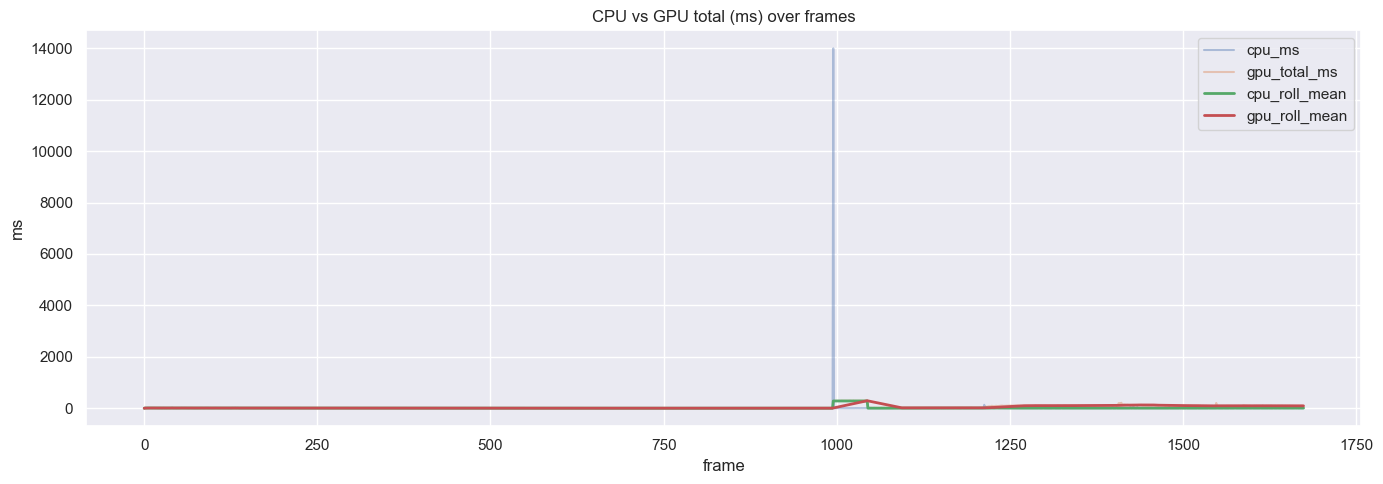

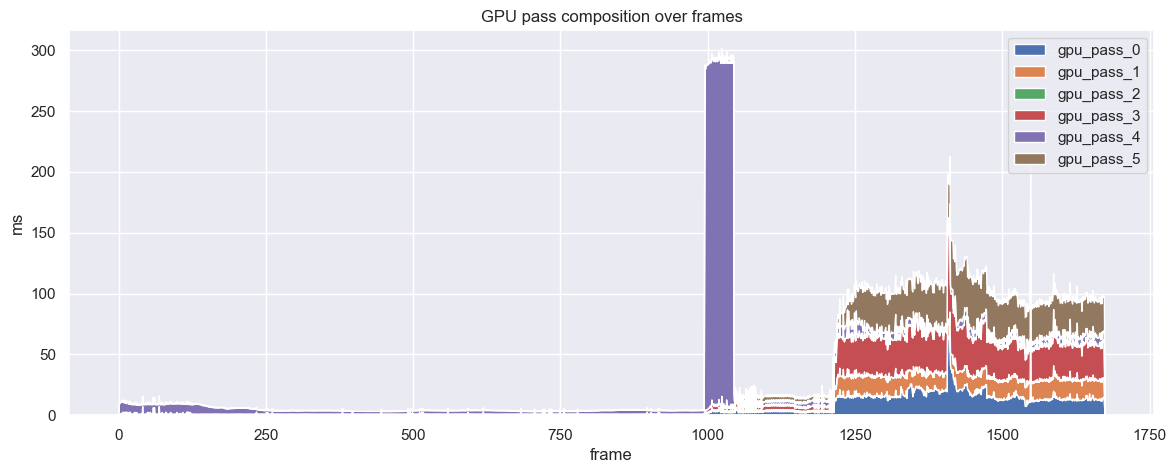

In [27]:
# Section 6 — Visualization: CPU vs GPU over frames
plt.figure(figsize=(14,5))
plt.plot(df['frame'], df['cpu_ms'], label='cpu_ms', alpha=0.4)
plt.plot(df['frame'], df['gpu_total_ms'], label='gpu_total_ms', alpha=0.4)
plt.plot(df['frame'], df['cpu_roll_mean'], label='cpu_roll_mean', linewidth=2)
plt.plot(df['frame'], df['gpu_roll_mean'], label='gpu_roll_mean', linewidth=2)
plt.xlabel('frame')
plt.ylabel('ms')
plt.title('CPU vs GPU total (ms) over frames')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(profile_dir / 'cpu_gpu_over_time.png')
plt.show()

# Stacked area of GPU passes
if len(gpu_cols) > 0:
    plt.figure(figsize=(14,5))
    plt.stackplot(df['frame'], [df[c] for c in gpu_cols], labels=gpu_cols)
    plt.legend(loc='upper right')
    plt.title('GPU pass composition over frames')
    plt.xlabel('frame')
    plt.ylabel('ms')
    plt.savefig(profile_dir / 'gpu_pass_stacked.png')
    plt.show()


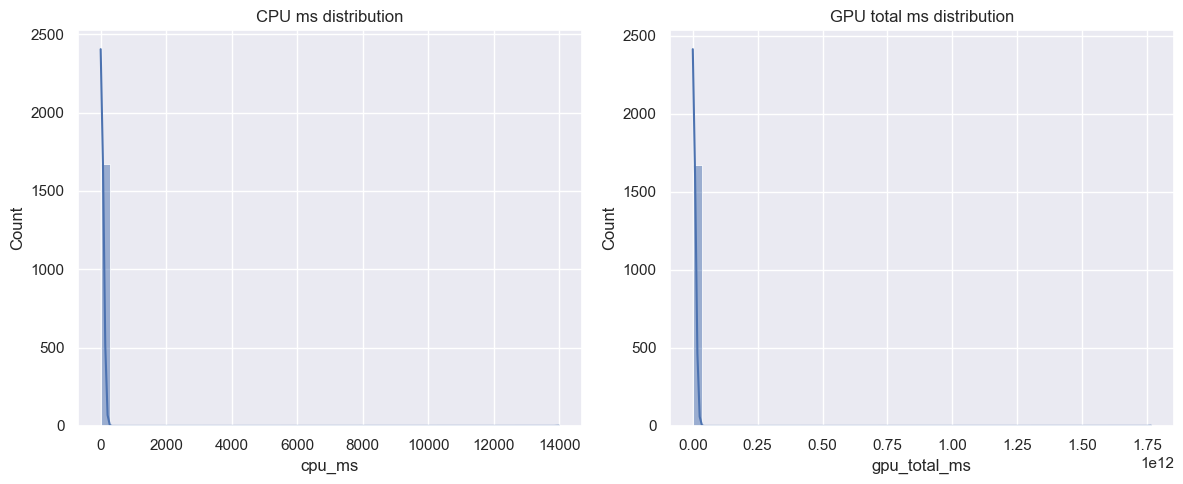

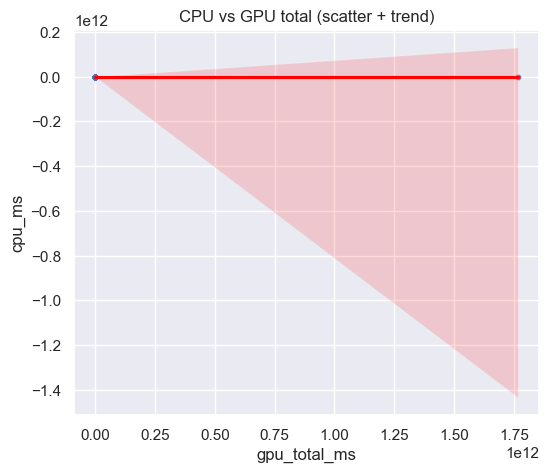


Correlation matrix:


,cpu_ms,gpu_total_ms
cpu_ms,1.000000,-0.000748
gpu_total_ms,-0.000748,1.000000


In [21]:
# Section 7 — Distributions & correlation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['cpu_ms'], bins=50, kde=True)
plt.title('CPU ms distribution')
plt.subplot(1,2,2)
sns.histplot(df['gpu_total_ms'], bins=50, kde=True)
plt.title('GPU total ms distribution')
plt.tight_layout()
plt.savefig(profile_dir / 'cpu_gpu_histograms.png')
plt.show()

# Scatter and correlation
plt.figure(figsize=(6,5))
sns.regplot(x='gpu_total_ms', y='cpu_ms', data=df, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title('CPU vs GPU total (scatter + trend)')
plt.savefig(profile_dir / 'cpu_vs_gpu_scatter.png')
plt.show()

print('\nCorrelation matrix:')
display(df[['cpu_ms','gpu_total_ms']].corr())

In [30]:
# Section 8 — Detect spikes / outliers
cpu_mean = df['cpu_ms'].mean(); cpu_std = df['cpu_ms'].std()
gpu_mean = df['gpu_total_ms'].mean(); gpu_std = df['gpu_total_ms'].std()

cpu_thresh = cpu_mean + 2 * cpu_std
gpu_thresh = gpu_mean + 2 * gpu_std

spikes_cpu = df[df['cpu_ms'] > cpu_thresh].sort_values('cpu_ms', ascending=False)
spikes_gpu = df[df['gpu_total_ms'] > gpu_thresh].sort_values('gpu_total_ms', ascending=False)

print(f"CPU mean={cpu_mean:.3f} ms, std={cpu_std:.3f}, threshold={cpu_thresh:.3f}")
print(f"GPU mean={gpu_mean:.3f} ms, std={gpu_std:.3f}, threshold={gpu_thresh:.3f}")

print('\nTop CPU spikes:')
display(spikes_cpu.head(20))
print('\nTop GPU spikes:')
display(spikes_gpu.head(20))

# Save spike summaries (use pd.concat instead of deprecated DataFrame.append)
summary_path = profile_dir / 'analysis_summary.csv'
combined = pd.concat([spikes_cpu.head(20).assign(type='cpu'), spikes_gpu.head(20).assign(type='gpu')], ignore_index=True)
combined.to_csv(summary_path, index=False)
print('\nSaved top spikes to', summary_path)

CPU mean=12.479 ms, std=341.847, threshold=696.173
GPU mean=215.476 ms, std=262.155, threshold=739.786

Top CPU spikes:


,frame,cpu_ms,gpu_pass_0,gpu_pass_1,gpu_pass_2,gpu_pass_3,gpu_pass_4,gpu_pass_5,gpu_pass_6,gpu_pass_7,gpu_pass_8,gpu_pass_9,gpu_total_ms
995,995,13992.763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Top GPU spikes:


,frame,cpu_ms,gpu_pass_0,gpu_pass_1,gpu_pass_2,gpu_pass_3,gpu_pass_4,gpu_pass_5,gpu_pass_6,gpu_pass_7,gpu_pass_8,gpu_pass_9,gpu_total_ms
1410,1410,2.074,62.823,10.876,0.001,73.700,3.94340,38.06858,189.41198,3.94340,114.709956,497.477316,994.954633
1412,1412,3.926,40.851,10.879,0.002,51.732,3.95400,39.34454,146.76254,3.95400,117.425827,414.904907,829.809814
1416,1416,2.322,37.495,11.981,0.002,49.478,3.99056,40.49462,143.44118,3.99056,120.166926,411.039846,822.079693
1415,1415,3.332,34.606,15.101,0.001,49.708,4.00690,40.17404,143.59694,4.00690,119.406007,410.606787,821.213574
1414,1414,3.699,37.484,12.433,0.001,49.918,3.99010,39.93476,143.76086,3.99010,118.812281,410.324101,820.648202
1413,1413,3.623,37.708,12.069,0.001,49.778,3.97284,39.57736,143.10620,3.97284,117.984850,408.170090,816.340180
1420,1420,3.069,31.015,16.016,0.002,47.033,3.97184,41.28956,139.32740,3.97184,122.270543,404.897183,809.794366
1418,1418,2.500,29.927,15.722,0.001,45.650,3.99316,40.87352,136.16668,3.99316,121.173737,397.500257,795.000514
1440,1440,2.029,25.947,14.849,0.001,40.797,6.90564,42.35784,130.85748,6.90564,128.093996,396.714596,793.429192
1439,1439,3.118,24.925,15.495,0.004,40.424,6.90488,42.22668,129.97956,6.90488,127.612357,394.476357,788.952714



Saved top spikes to profile\analysis_summary.csv


In [31]:
# Section 9 — Dimensionality reduction & clustering (on per-pass features)
if len(gpu_cols) > 1 and sklearn is not None:
    X = df[gpu_cols].copy()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    comps = pca.fit_transform(Xs)
    kmeans = KMeans(n_clusters=3, random_state=0).fit(comps)
    plt.figure(figsize=(8,6))
    plt.scatter(comps[:,0], comps[:,1], c=kmeans.labels_, cmap='tab10', s=10)
    plt.title('PCA of GPU passes (colored by KMeans cluster)')
    plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.savefig(profile_dir / 'pca_gpu_passes.png')
    plt.show()
    print('Explained variance ratio:', pca.explained_variance_ratio_)
else:
    print('Not enough GPU-pass features or sklearn not available to run PCA/clustering.')


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [32]:
# Section 10 — Model explainability placeholder
# If a model is provided, compute feature importances or SHAP values as available.
# This project may not have a saved model; we attempt to locate one but continue if none.
model_files = list(Path('.').glob('**/*.joblib')) + list(Path('.').glob('**/*.pkl')) + list(Path('.').glob('**/*.pt'))
if model_files:
    print('Found model file(s):', model_files[:5])
    if joblib is not None and model_files[0].suffix in ['.joblib', '.pkl']:
        model = joblib.load(model_files[0])
        print('Loaded model via joblib:', model)
    else:
        print('Model file found but automatic load not implemented for this format in this notebook. Please load manually.')
else:
    print('No saved model detected; skipping model explainability and prediction cells.')


Found model file(s): [WindowsPath('.venv/Lib/site-packages/numpy/_core/tests/data/astype_copy.pkl')]


ValueError: You may be trying to read with python 3 a joblib pickle generated with python 2. This feature is not supported by joblib.

In [33]:
# Section 11 — Aggregate results and export
summary_dict = {
    'cpu_mean_ms': float(cpu_mean),
    'cpu_median_ms': float(df['cpu_ms'].median()),
    'gpu_mean_ms': float(gpu_mean),
    'gpu_median_ms': float(df['gpu_total_ms'].median()),
    'frames': int(df.shape[0])
}

# top 5 contributing GPU passes by avg
pass_means = df[gpu_cols].mean().sort_values(ascending=False)
summary_dict['top_gpu_passes'] = pass_means.head(5).to_dict()

# Write summary JSON and CSV
summary_json = profile_dir / 'analysis_summary.json'
with open(summary_json, 'w') as fh:
    json.dump(summary_dict, fh, indent=2)
print('Saved JSON summary to', summary_json)

# Also save a quick summary CSV
summary_df = pd.DataFrame([summary_dict])
summary_df.to_csv(profile_dir / 'analysis_summary_basic.csv', index=False)
print('Saved CSV summary to', profile_dir / 'analysis_summary_basic.csv')


Saved JSON summary to profile\analysis_summary.json
Saved CSV summary to profile\analysis_summary_basic.csv


In [34]:
# Section 12 — Reproducibility checks & final notes
import random
seed = 42
np.random.seed(seed)
random.seed(seed)

# Basic checks
assert df.shape[0] > 0, "No frames loaded"
assert (df[['cpu_ms','gpu_total_ms']] >= 0).all().all(), "Negative timing values found"

print('Reproducibility checks passed.\n')

# Final notes and next steps
print('Next steps:')
print('1) Inspect the saved images in profile/*.png for visual trends (cpu_gpu_over_time.png, gpu_pass_stacked.png).')
print('2) Share `profile/analysis_summary.csv` and `profile/analysis_summary_basic.csv` for review.')
print('3) If training or predictive models are needed, export features and labels to `profile/features.csv` and add a model in `models/` to load here.')


AssertionError: Negative timing values found